# Assignment 1: Combined Cycle Power Plant Data Set

Name: *Pratham Aggarwal* | Github: *prathamaeron* | USC ID: *1537722913*

## Importing the Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix
import statsmodels.api as sm

## Exploring the Data

(i) From a look at Folds5x2_pp.xlsx, we can see that there are 5 columns and 9568 rows. The columns represent the hourly ambient variables: Temperature (AT), Ambient Pressure (AP), Relative Humidity (RH) and Exhaust Vacuum (V). These 4 variables are use to predict the net hourly electrical energy output (PE) of the plant. Below, I have imported this data.

In [2]:
data = pd.read_excel("../data/Folds5x2_pp.xlsx")
data.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


(ii) Make pairwise scatterplots of all variables in the data set including the predictors (independent variables) with the dependent variable. Describe your findings.

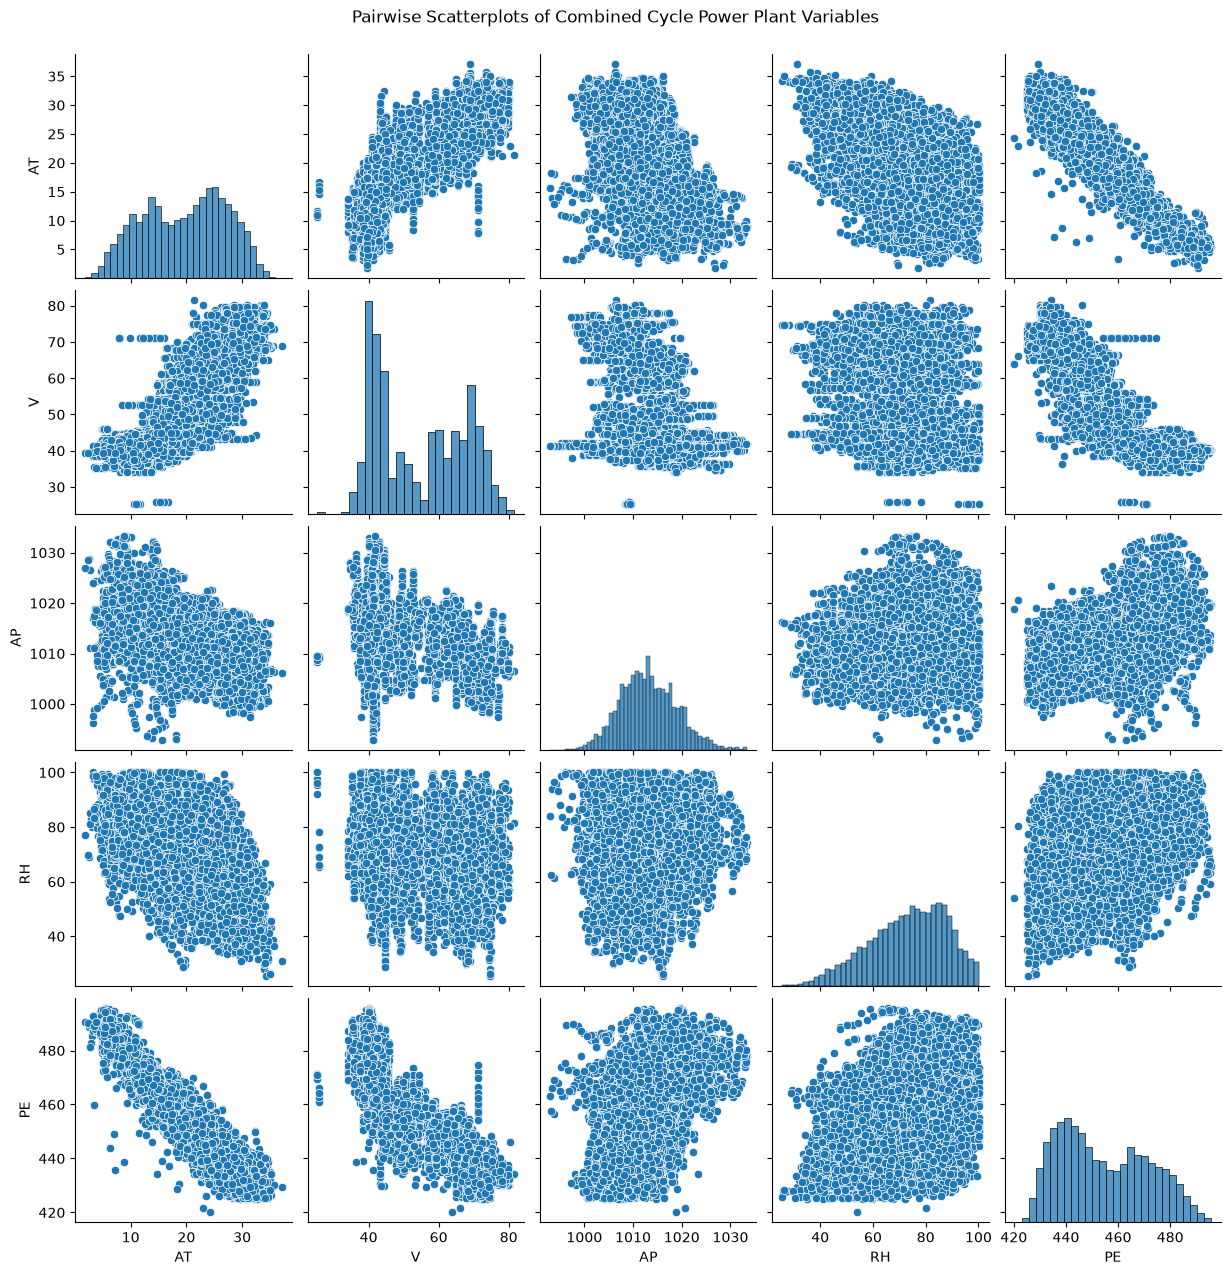

In [3]:
sns.pairplot(data, diag_kind="hist")
plt.suptitle("Pairwise Scatterplots of Combined Cycle Power Plant Variables", y=1.02)
plt.show()

The scatterplots show that PE has a strong negative relationship with AT and V. PE also has a weaker negative relationship with RH and a moderate positive relationship with AP. AT and V appear to have a strong positive relationship. The relationships between the remaining predictor variables are comparatively weaker. The diagonal histograms show the distributions of each variable.

(iii) What are the mean, the median, range, first and third quartiles, and interquartile ranges of each of the variables in the dataset? Summarize them in a table.

In [4]:
summary = data.describe().T

summary["range"] = summary["max"] - summary["min"]
summary["IQR"] = summary["75%"] - summary["25%"]

summary = summary.rename(columns={
    "mean": "Mean",
    "50%": "Median",
    "min": "Minimum",
    "max": "Maximum",
    "25%": "Q1",
    "75%": "Q3"
})

summary[["Mean", "Median", "Minimum", "Maximum", "range", "Q1", "Q3", "IQR"]].round(2)

,Mean,Median,Minimum,Maximum,range,Q1,Q3,IQR
AT,19.65,20.34,1.81,37.11,35.30,13.51,25.72,12.21
V,54.31,52.08,25.36,81.56,56.20,41.74,66.54,24.80
AP,1013.26,1012.94,992.89,1033.30,40.41,1009.10,1017.26,8.16
RH,73.31,74.97,25.56,100.16,74.60,63.33,84.83,21.50
PE,454.37,451.55,420.26,495.76,75.50,439.75,468.43,28.68


## Simple Linear Regression Model

(c) For each predictor, fit a simple linear regression model to predict the response. Describe your results. In which of the models is there a statistically significant association between the predictor and the response? Create some plots to back up your assertions. Are there any outliers that you would like to remove from your data for each of these regression tasks?

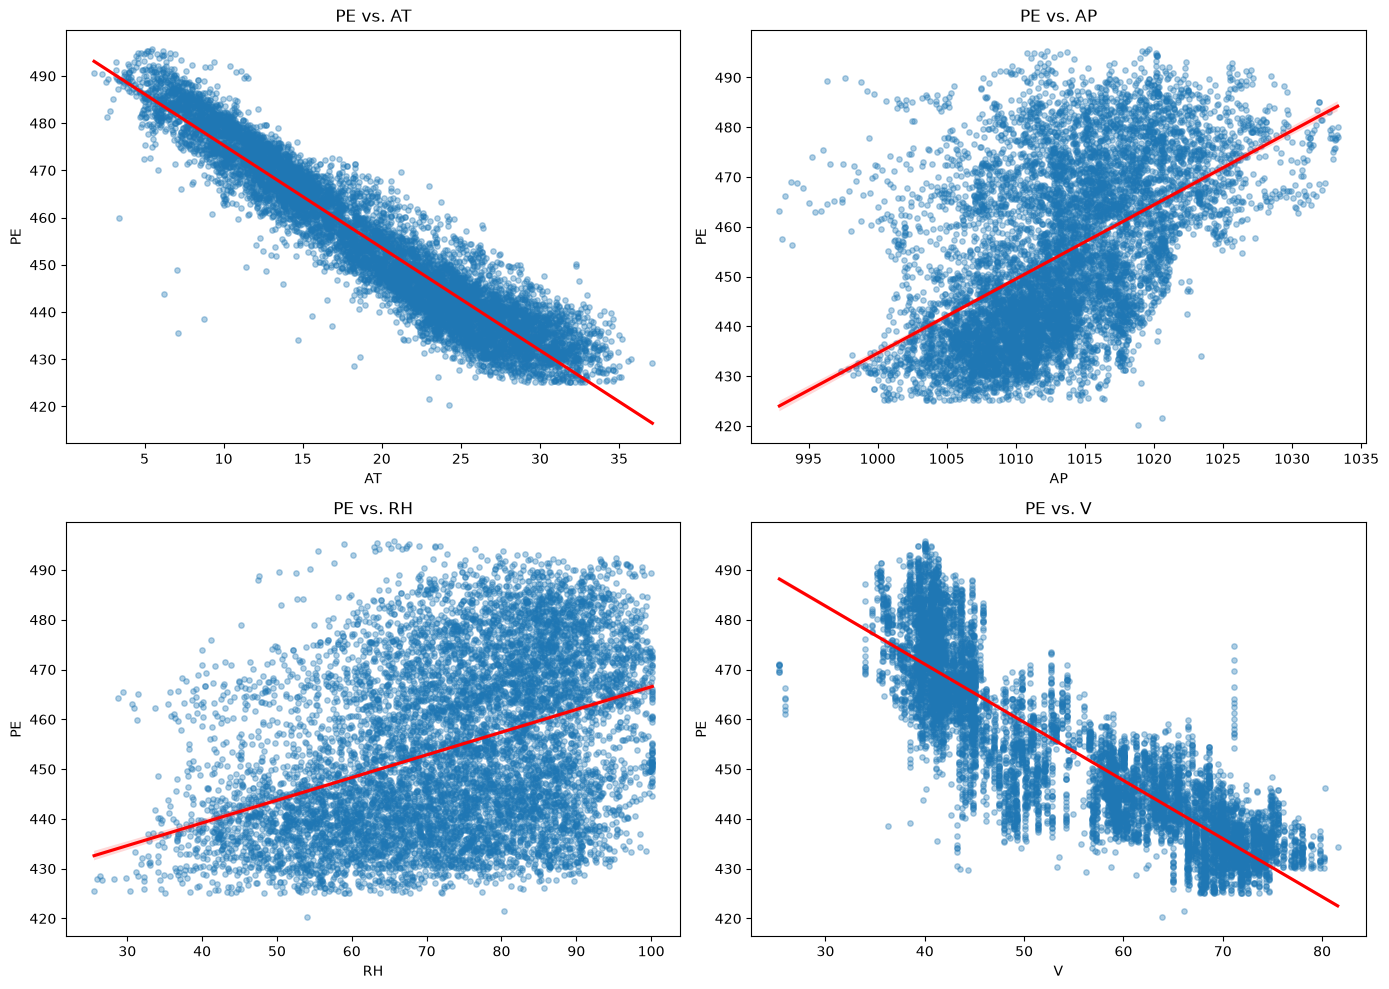

,Predictor,Intercept,Slope,R-squared,p-value,Outliers (|studentized residual| > 3)
0,AT,497.0341,-2.1713,0.8989,0.0,42
1,AP,-1055.2610,1.4899,0.2688,0.0,29
2,RH,420.9618,0.4557,0.1519,0.0,2
3,V,517.8015,-1.1681,0.7565,0.0,33


In [6]:
predictors = ["AT", "AP", "RH", "V"]
response = "PE"
results = []

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for ax, predictor in zip(axes, predictors):
    X = sm.add_constant(data[predictor])
    y = data[response]

    model = sm.OLS(y, X).fit()
    influence = model.get_influence()
    studentized_residuals = influence.resid_studentized_internal
    outliers = np.abs(studentized_residuals) > 3

    results.append({
        "Predictor": predictor,
        "Intercept": model.params["const"],
        "Slope": model.params[predictor],
        "R-squared": model.rsquared,
        "p-value": model.pvalues[predictor],
        "Outliers (|studentized residual| > 3)": outliers.sum()
    })

    sns.regplot(
        x=data[predictor],
        y=data[response],
        ax=ax,
        scatter_kws={"alpha": 0.35, "s": 15},
        line_kws={"color": "red"}
    )
    ax.set_title(f"PE vs. {predictor}")
    ax.set_xlabel(predictor)
    ax.set_ylabel("PE")

plt.tight_layout()
plt.show()

regression_results = pd.DataFrame(results)
regression_results.round(4)

Each predictor was used separately to fit a simple linear regression model for predicting PE. The regression plots show that AT and V have strong negative linear associations with PE. RH has a weaker negative association, while AP has a weak positive association.

Because the sample size is large, all four predictors have statistically significant associations with PE at the 5% significance level (p-value < 0.05). However, statistical significance does not imply that all predictors have equally strong predictive power. The R-squared values indicate that AT and V explain substantially more variation in PE than AP and RH.

Potential outliers were identified using internally studentized residuals with an absolute value greater than 3. These observations should be investigated, but they were not removed because they may represent valid operating conditions of the power plant.

## Multiple Regression Model


(d) Fit a multiple regression model to predict the response using all of the predictors. Describe your results. For which predictors can we reject the null hypothesis $H_0 : \beta_j = 0$?


In [7]:
X = sm.add_constant(data[["AT", "AP", "RH", "V"]])
y = data["PE"]

multiple_model = sm.OLS(y, X).fit()

print(multiple_model.summary())

multiple_results = pd.DataFrame({
    "Coefficient": multiple_model.params,
    "p-value": multiple_model.pvalues,
    "Significant at 5%": multiple_model.pvalues < 0.05
})

multiple_results.round(6)

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Tue, 22 Sep 2026   Prob (F-statistic):               0.00
Time:                        22:40:51   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        454.6093      9.749     46.634      0.0

,Coefficient,p-value,Significant at 5%
const,454.609274,0.0,True
AT,-1.977513,0.0,True
AP,0.062083,0.0,True
RH,-0.158054,0.0,True
V,-0.233916,0.0,True


The multiple regression model uses AT, AP, RH, and V simultaneously to predict PE. The model explains approximately 93% of the variation in PE, indicating a strong overall fit.

The estimated coefficients for AT, RH, and V are negative, while the coefficient for AP is positive. Holding the other predictors constant, higher temperature, relative humidity, and exhaust vacuum are associated with lower electrical energy output. Higher ambient pressure is associated with slightly higher electrical energy output.

At the 5% significance level, we reject the null hypothesis $H_0:\beta_j=0$ for all four predictors because their p-values are less than 0.05. Therefore, each predictor has a statistically significant partial association with PE after controlling for the other predictors.

## Analysis

(e) How do your results from 1c compare to your results from 1d? Create a plot displaying the univariate regression coefficients from 1c on the x-axis, and the multiple regression coefficients from 1d on the y-axis. That is, each predictor is displayed as a single point in the plot. Its coefficient in a simple linear regression model is shown on the x-axis, and its coefficient estimate in the multiple linear regression model is shown on the y-axis.

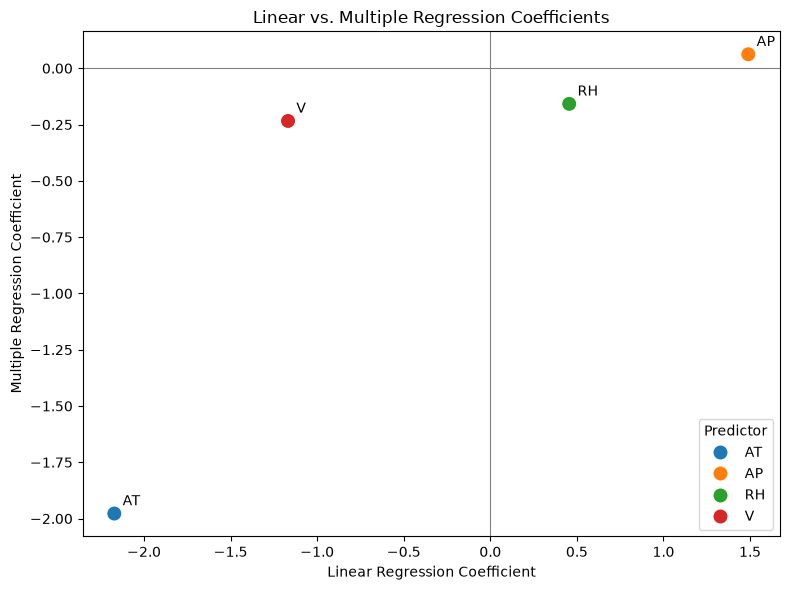

,Predictor,Slope,Multiple Coefficient
0,AT,-2.1713,-1.9775
1,AP,1.4899,0.0621
2,RH,0.4557,-0.1581
3,V,-1.1681,-0.2339


In [10]:
comparison = regression_results[["Predictor", "Slope"]].copy()
comparison["Multiple Coefficient"] = comparison["Predictor"].map(
    multiple_model.params
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=comparison,
    x="Slope",
    y="Multiple Coefficient",
    hue="Predictor",
    s=120
)

for _, row in comparison.iterrows():
    plt.annotate(
        row["Predictor"],
        (row["Slope"], row["Multiple Coefficient"]),
        xytext=(6, 6),
        textcoords="offset points"
    )

plt.xlabel("Linear Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Linear vs. Multiple Regression Coefficients")
plt.axhline(0, color="gray", linewidth=0.8)
plt.axvline(0, color="gray", linewidth=0.8)
plt.legend(title="Predictor")
plt.tight_layout()
plt.show()

comparison.round(4)

The linear and multiple regression coefficients have the same general signs: AT, RH, and V have negative coefficients, while AP has a positive coefficient. However, their magnitudes differ because the multiple regression model controls for the relationships among all predictors. In particular, correlations among the predictors can cause the multiple regression coefficients to differ substantially from the linear coefficients. AT and V have the largest effects in both models, while AP and RH have comparatively smaller effects.